### 멀티모달 RAG
- 01.multimodal 에서 추출한 텍스트와 이미지요약본을 VectorDB에 임베딩하고 

    사용자의 질문에 맞춰 관련 컨텍스트를 검색(Retrival)한뒤 LLM을 이용해서 최종 답변을 생성(Generation)

In [32]:
import os
import fitz
from dotenv import load_dotenv
from openai import OpenAI
import chromadb
from chromadb.utils import embedding_functions

In [33]:
# 환경변수 로드 및 openai 클라이언트 생성
load_dotenv(override=True)
client = OpenAI()

In [34]:
# 벡터 Db 초기화
chroma_client = chromadb.PersistentClient(path='./chroma_db')
openai_ef = embedding_functions.OpenAIEmbeddingFunction(
    api_key=os.getenv('OPENAI_API_KEY'),
    model_name = 'text-embedding-3-small'
)
if chroma_client.count_collections() != 0:
    chroma_client.delete_collection('multimodal_rag')
collection = chroma_client.get_or_create_collection(name='multimodal_rag',embedding_function=openai_ef)
print(f'설정완료 현재 컬렉션의 크기 : {collection.count()}')

설정완료 현재 컬렉션의 크기 : 0


### 데이터 임베딩(텍스트 + 이미지 요약본)
- pdf의 텍스트와 이미지 요약본을 모두 VectorDB에 삽입(동일한 벡터공간에 텍스트와 이미지 요약본이 함께 존재)

In [35]:
import base64
if collection.count() == 0:
    pdf_path = 'sample_paper.pdf'
    doc = fitz.open(pdf_path)
    documents = []
    metatdatas = []    
    ids = []
    
    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        # 텍스트 추출
        text = page.get_text()
        if text.strip():
            documents.append(text)
            metatdatas.append({'page':page_num+1,'type':'text'})
            ids.append(f'text_page_{page_num+1}')
        # 이미지 요약 후 추출
        image_list = page.get_images(full=True)
        if image_list:
            xref = image_list[0][0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image['image']
            ext = base_image['ext']
            if ext.lower() == 'jb2': ext = 'jpeg'
            mime_type = f'image/{ext}' if ext.lower() != "jpg" else 'image/jpeg'
            base64_image = base64.b64encode(image_bytes).decode('utf-8')
            try:
                response = client.chat.completions.create(
                    model = 'gpt-5.4-nano',
                    messages=[
                        {'role':'user', 
                        'content': [
                            {'type':'text', 'text':'이 이미지에 대한 상세한 설명을 작성해 주세요. 전문적이고 구체적으로 분석해야 합니다.'},
                            {'type':'image_url', 'image_url':{
                                'url':f'data:{mime_type};base64,{base64_image}'
                                }
                            }
                        ]
                        }
                    ],
                    # max_completion_tokens=300
                )
                summary = response.choices[0].message.content
                documents.append(summary)
                metatdatas.append({
                    'type':'image_summary',
                    'page':page_num+1,
                    'image_base64' : base64_image,
                    'mime_type':mime_type

                })
                ids.append(f'image_summary_page_{page_num+1}')
            except Exception as e:
                pass
    if documents:
        collection.add(documents=documents,metadatas=metatdatas,ids=ids)
        print('VectorDB에 데이터 임베딩 및 저장 완료')
else:
    print(f'vectorDB에 이미 {collection.count()}개 데이터가 존재합니다')


VectorDB에 데이터 임베딩 및 저장 완료


### 질문을 통해 RAG 검색하기

아래 이미지는 **Transformer(트랜스포머) 모델의 인코더-디코더 구조**를 도식화한 것입니다. 특히 “**Self-Attention(멀티-헤드 어텐션)** + **Add & Norm(잔차 연결과 정규화)**” 블록을 반복하며, 최상단에는 **Linear → Softmax**로 최종 확률을 계산하는 과정을 보여줍니다.  

---

## 1) 전체 구성(입력 → 인코더 → 디코더 → 출력)
- 이미지 하단 왼쪽: **Inputs**
  - **Input Embedding**(입력 토큰을 벡터로 임베딩)
  - 그 위에 **Positional Encoding**(위치 정보 추가)
- 이미지 좌측 중간~하단: **Encoder 스택**
  - “N×” 표기로 동일 구조를 여러 층 쌓았음을 나타냄
- 이미지 우측 중간~상단: **Decoder 스택**
  - 역시 “N×”로 여러 층 반복
- 이미지 하단 오른쪽: **Outputs**
  - **Output Embedding**(디코더 입력으로 들어가는 토큰 임베딩)
  - “(shifted right)” 표기: 디코더는 정답 시퀀스를 **오른쪽으로 한 칸 밀어**(teacher forcing) 다음 토큰 예측 입력으로 사용

---

## 2) Embedding & Positional Encoding(하단 영역)
- **Input Embedding / Output Embedding**
  - 토큰 ID를 모델이 다룰 수 있는 고정 차원의 벡터로 변환합니다.
- **Positional Encoding**
  - Transformer는 순서를 직접 처리하지 않으므로, 각 토큰 위치의 정보를 **사인/코사인 등으로 만든 위치 인코딩**(원형 물결 아이콘)을 임베딩 벡터에 **더하기(+)** 연산으로 결합합니다.
  - 이미지에서 “+” 표시는 **임베딩 + 위치인코딩**을 의미합니다.

---

## 3) Encoder 블록(좌측 “N×” 영역)
Encoder 쪽에는 2개의 핵심 서브레이어가 **반복적으로 구성*

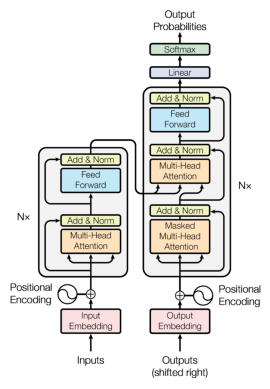

In [44]:
query = '논문에 나온 트랜스포커 아키텍처 다이어그램(인코더-디코더 그림)에 대해 설명해주세요'
results = collection.query(
    query_texts=[query],
    n_results=1
)
retrieved_docs = results['documents'][0][0]
retrieved_metas = results['metadatas'][0][0]
print(retrieved_docs)
# base64를 디코딩해서 출력
image_bytes = base64.b64decode(retrieved_metas['image_base64'])
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
img = Image.open(BytesIO(image_bytes))
plt.imshow(img)
plt.axis('off')
plt.show()


 query

 vector search

 image 발견

 LLM 에 이미지와 사용자질문 이미지요약설명

 최종 답변